# Neural ODE / Continious Normalizing on MNIST-Dataset

In [2]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchdiffeq import odeint_adjoint
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons

# if nvidia gpu available use it
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Device:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("Supported archs:", torch.cuda.get_arch_list())

PyTorch: 2.11.0+cu130
CUDA available: False


## 1. Loading MNIST-Dataset

In [31]:
# download test and trainset of mnist via pytorchvision
# define a transformation from PIL to tensor with normalized pixels
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# download mnist dataset
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# define dataloader and get images
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
images = train_set.data
labels = train_set.targets

print()
print(train_set)
print()
print("shape images: ", images.shape)


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

shape images:  torch.Size([60000, 28, 28])


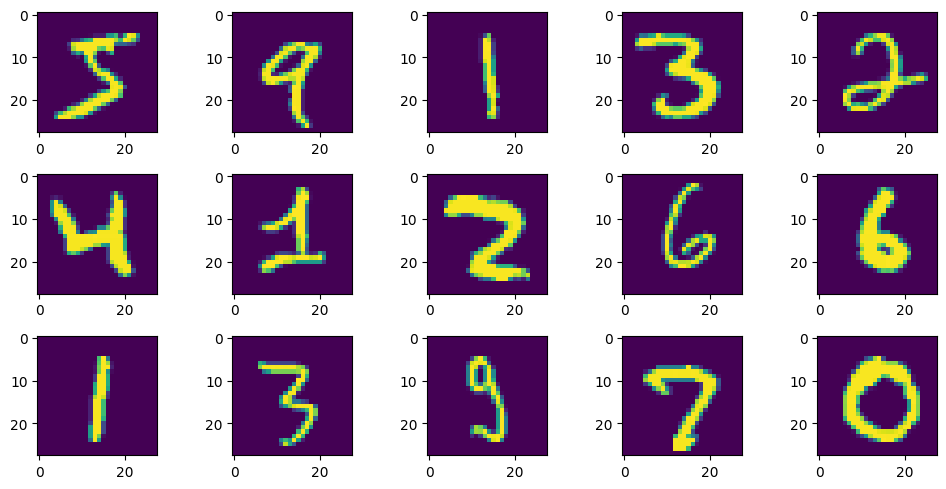

In [55]:
# plot example images
fig, ax = plt.subplots(3, 5, figsize=(10, 5))
ax = ax.flatten()
for i in range(0, 60, 4):
    ax[int(i/4)].imshow(images[i])
fig.tight_layout()